## 3.11 양자 이미지 처리 (Quantum Image Processing, QIP)

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import array_to_latex, plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 간단한 2x2 회색조 이미지 정의
image = np.array([[0, 255], [255, 0]])

In [3]:
# 픽셀 값을 [0, 1]로 정규화
image_normalized = image / 255.0

In [4]:
# 이미지를 평탄화해 벡터 생성
image_vector = image_normalized.flatten()

In [5]:
# 진폭 제곱의 합이 1이 되도록 벡터 정규화
norm = np.linalg.norm(image_vector)
image_vector = image_vector / norm

In [6]:
# 큐비트 2개로 양자 회로 생성 (2x2 = 4픽셀이므로)
qc = QuantumCircuit(2)

In [7]:
# 양자 상태를 이미지 벡터로 초기화
qc.initialize(image_vector, [0, 1])

In [8]:
# 상태벡터 저장 명령 추가
qc.save_statevector()

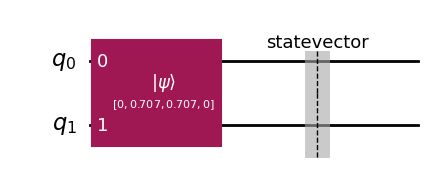

In [9]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [10]:
# AerSimulator용으로 회로 트랜스파일
simulator = AerSimulator()
transpiled_circuit = transpile(qc, simulator)

In [11]:
# 상태벡터를 얻기 위해 시뮬레이션 실행
result = simulator.run(transpiled_circuit).result()

In [12]:
# 실험 데이터에서 상태벡터 얻기
statevector = result.data()['statevector']

In [13]:
# 상태벡터를 latex로 시각화 (Qiskit 1.0)
print(array_to_latex(statevector))  # latex 표현 출력

<IPython.core.display.Latex object>


In [14]:
# 모든 큐비트 측정
qc.measure_all()

In [15]:
# 측정이 포함된 회로를 트랜스파일해 실행
transpiled_circuit_with_measurement = transpile(qc, simulator)
result_with_measurement = simulator.run(transpiled_circuit_with_measurement, shots=1024).result()

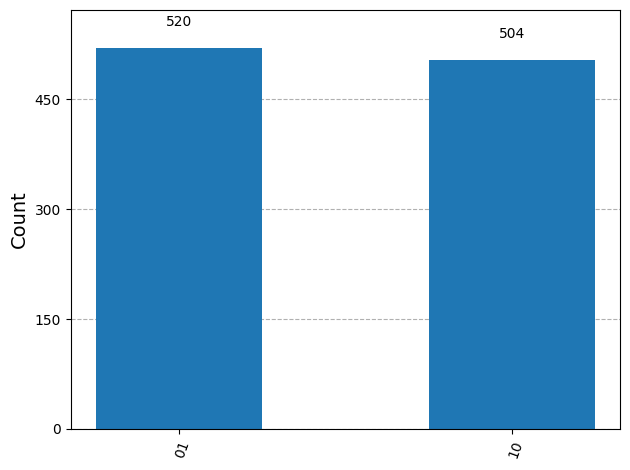

In [16]:
# 측정 결과 얻기
counts = result_with_measurement.get_counts()
plot_histogram(counts)
plt.show()